# 🤖 Models Training & Comparison Notebook
## Smoking Status Prediction — Feature Engineering + Model Development + Hyperparameter Tuning

**Contents:**
1. Setup & Load Splits
2. Feature Engineering & Preprocessing (Outlier Removal, Normalization, Feature Creation)
3. Model Development (Logistic Regression, Naïve Bayes, Neural Network)
4. Hyperparameter Tuning (Grid Search)
5. Model Comparison & Final System


## 1. Setup & Load Data Splits

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from sklearn.model_selection import GridSearchCV, cross_val_score
from scipy import stats

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (10, 5)})

tf.random.set_seed(42)
np.random.seed(42)

print("✅ All libraries loaded")
print(f"   TensorFlow: {tf.__version__}")


✅ All libraries loaded
   TensorFlow: 2.21.0


In [6]:
# ── Load the pre-split CSVs created in exploratory.ipynb ──────────────────────
train_df = pd.read_csv("train.csv")
val_df   = pd.read_csv("val.csv")
test_df  = pd.read_csv("test.csv")

TARGET = "smoking"
FEATURES = [c for c in train_df.columns if c != TARGET]

X_train_raw = train_df[FEATURES].copy()
y_train      = train_df[TARGET].values

X_val_raw   = val_df[FEATURES].copy()
y_val        = val_df[TARGET].values

X_test_raw  = test_df[FEATURES].copy()
y_test       = test_df[TARGET].values

print(f"Train : {X_train_raw.shape}  |  Val : {X_val_raw.shape}  |  Test : {X_test_raw.shape}")
print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"\nClass distribution (train): {dict(zip(*np.unique(y_train, return_counts=True)))}")


Train : (111479, 10)  |  Val : (23888, 10)  |  Test : (23889, 10)
Features (10): ['eyesight(right)', 'ALT', 'triglyceride', 'fasting blood sugar', 'LDL', 'waist(cm)', 'hearing(right)', 'AST', 'hearing(left)', 'Cholesterol']

Class distribution (train): {np.int64(0): np.int64(62722), np.int64(1): np.int64(48757)}


## 2. Feature Engineering & Preprocessing

### Pipeline:
1. **Outlier Removal** — IQR method on training set only (to avoid data leakage)
2. **Log-transform** — for highly skewed features (|skew| > 1)
3. **Normalization** — StandardScaler, MinMaxScaler, and RobustScaler compared
4. **Feature Creation** — interaction and ratio features


In [7]:
# ══ 2.1  Outlier Removal (IQR — applied only on training set) ═══════════════
def remove_outliers_iqr(df, features, multiplier=1.5):
    """Return mask of rows that are NOT outliers in any of the given features."""
    mask = pd.Series(True, index=df.index)
    for feat in features:
        Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - multiplier * IQR, Q3 + multiplier * IQR
        mask &= df[feat].between(lower, upper)
    return mask

# Identify numerical features
num_feats = X_train_raw.select_dtypes(include=np.number).columns.tolist()

# IQR outlier removal on training set
train_all = X_train_raw.copy()
train_all[TARGET] = y_train
mask = remove_outliers_iqr(train_all, num_feats)
train_clean = train_all[mask].copy()

X_train_clean = train_clean[FEATURES]
y_train_clean = train_clean[TARGET].values

removed = len(X_train_raw) - len(X_train_clean)
print(f"Outlier removal: removed {removed} rows "
      f"({removed/len(X_train_raw)*100:.1f}% of training data)")
print(f"Training set size after cleaning: {X_train_clean.shape}")


Outlier removal: removed 19772 rows (17.7% of training data)
Training set size after cleaning: (91707, 10)


In [8]:
# ══ 2.2  Skewness Check & Log-Transform ══════════════════════════════════════
skew_series = X_train_clean[num_feats].skew().abs()
skewed_feats = skew_series[skew_series > 1].index.tolist()
print(f"Highly skewed features (|skew| > 1): {skewed_feats}")

def log_transform(df, feats):
    df = df.copy()
    for f in feats:
        if f in df.columns:
            # log1p handles zeros safely
            df[f] = np.log1p(df[f].clip(lower=0))
    return df

X_train_log = log_transform(X_train_clean, skewed_feats)
X_val_log   = log_transform(X_val_raw,   skewed_feats)
X_test_log  = log_transform(X_test_raw,  skewed_feats)

# Visualise effect of log-transform
if skewed_feats:
    fig, axes = plt.subplots(2, len(skewed_feats[:4]), figsize=(14, 6))
    for i, feat in enumerate(skewed_feats[:4]):
        axes[0, i].hist(X_train_clean[feat], bins=40, color="#5B8DB8", alpha=0.8)
        axes[0, i].set_title(f"{feat}\n(before, skew={X_train_clean[feat].skew():.2f})")
        axes[1, i].hist(X_train_log[feat],   bins=40, color="#E07B54", alpha=0.8)
        axes[1, i].set_title(f"{feat}\n(after log, skew={X_train_log[feat].skew():.2f})")
    plt.suptitle("Log-Transform Effect on Skewed Features", fontweight="bold")
    plt.tight_layout()
    plt.savefig("fe_log_transform.png", bbox_inches="tight")
    plt.show()


Highly skewed features (|skew| > 1): []


In [9]:
# ══ 2.3  Feature Creation ═════════════════════════════════════════════════════
# Create meaningful interaction / ratio features from the domain
def add_engineered_features(df):
    df = df.copy()
    cols = df.columns.tolist()

    # Liver function ratio (if both available)
    if "ALT" in cols and "AST" in cols:
        df["ALT_AST_ratio"] = df["ALT"] / (df["AST"] + 1e-6)

    # Hearing average (if both channels available)
    if "hearing(left)" in cols and "hearing(right)" in cols:
        df["hearing_avg"] = (df["hearing(left)"] + df["hearing(right)"]) / 2
        df["hearing_diff"] = (df["hearing(left)"] - df["hearing(right)"]).abs()

    # Lipid ratio
    if "cholesterol" in cols and "LDL" in cols:
        df["chol_LDL_ratio"] = df["cholesterol"] / (df["LDL"] + 1e-6)

    # Waist × triglyceride interaction (metabolic risk)
    if "waist(cm)" in cols and "triglyceride" in cols:
        df["waist_trig_interaction"] = df["waist(cm)"] * df["triglyceride"]

    return df

X_train_fe = add_engineered_features(X_train_log)
X_val_fe   = add_engineered_features(X_val_log)
X_test_fe  = add_engineered_features(X_test_log)

new_feats = [f for f in X_train_fe.columns if f not in X_train_log.columns]
print(f"New engineered features ({len(new_feats)}): {new_feats}")
print(f"Total features after engineering: {X_train_fe.shape[1]}")


New engineered features (4): ['ALT_AST_ratio', 'hearing_avg', 'hearing_diff', 'waist_trig_interaction']
Total features after engineering: 14


In [10]:
# ══ 2.4  Normalization — Compare Three Scalers ════════════════════════════════
# We fit scalers ONLY on training data, then apply to val and test

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler":   MinMaxScaler(),
    "RobustScaler":   RobustScaler(),
}

scaled_sets = {}
for name, scaler in scalers.items():
    X_tr = scaler.fit_transform(X_train_fe)
    X_v  = scaler.transform(X_val_fe)
    X_te = scaler.transform(X_test_fe)
    scaled_sets[name] = (X_tr, X_v, X_te, scaler)
    print(f"{name:20s} — train mean≈{X_tr.mean():.3f}, std≈{X_tr.std():.3f}")

# Choose StandardScaler as primary (best for neural networks and logistic regression)
X_train_scaled, X_val_scaled, X_test_scaled, final_scaler = scaled_sets["StandardScaler"]
FEAT_NAMES_FE = X_train_fe.columns.tolist()
print(f"\n✅ Using StandardScaler for all models. Feature count: {X_train_scaled.shape[1]}")


StandardScaler       — train mean≈0.000, std≈0.845
MinMaxScaler         — train mean≈0.314, std≈0.261
RobustScaler         — train mean≈0.058, std≈0.602

✅ Using StandardScaler for all models. Feature count: 14


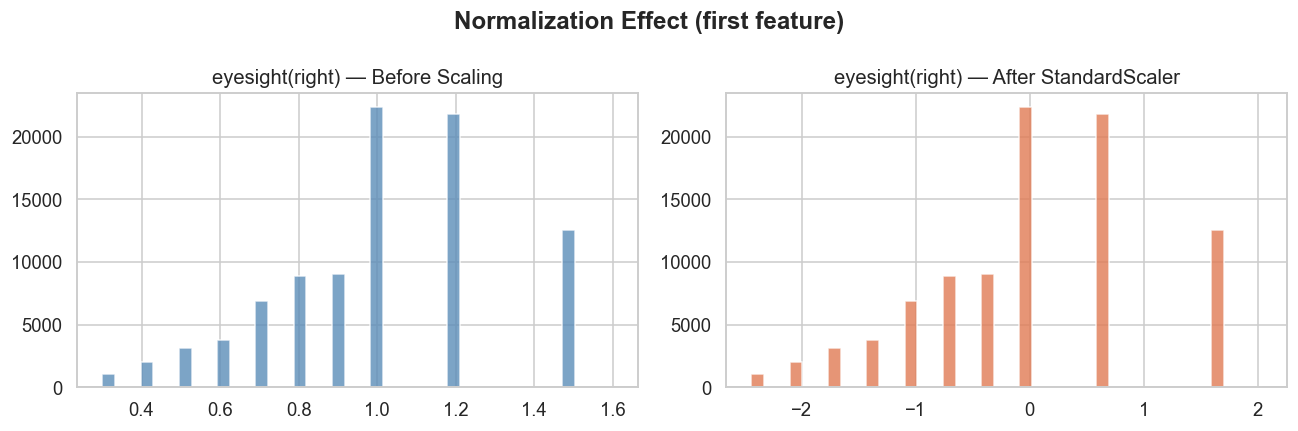


Preprocessing pipeline summary:
  1. Outlier removal (IQR): 19772 training rows removed
  2. Log-transform applied to: []
  3. New features created: ['ALT_AST_ratio', 'hearing_avg', 'hearing_diff', 'waist_trig_interaction']
  4. Normalization: StandardScaler (zero mean, unit variance)


In [11]:
# ══ 2.5  Visualise final feature distributions after preprocessing ════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before scaling
axes[0].hist(X_train_fe.iloc[:, 0], bins=40, color="#5B8DB8", alpha=0.8)
axes[0].set_title(f"{FEAT_NAMES_FE[0]} — Before Scaling")

# After scaling
axes[1].hist(X_train_scaled[:, 0], bins=40, color="#E07B54", alpha=0.8)
axes[1].set_title(f"{FEAT_NAMES_FE[0]} — After StandardScaler")

plt.suptitle("Normalization Effect (first feature)", fontweight="bold")
plt.tight_layout()
plt.savefig("fe_normalization_effect.png", bbox_inches="tight")
plt.show()

print("\nPreprocessing pipeline summary:")
print(f"  1. Outlier removal (IQR): {removed} training rows removed")
print(f"  2. Log-transform applied to: {skewed_feats}")
print(f"  3. New features created: {new_feats}")
print(f"  4. Normalization: StandardScaler (zero mean, unit variance)")


## 3. Model Development

Three models are trained and evaluated:
- **Model 1:** Logistic Regression (Linear)
- **Model 2:** Gaussian Naïve Bayes (Probabilistic)
- **Model 3:** Neural Network (Deep Learning via Keras)


In [12]:
# ══ Helper: evaluation function ════════════════════════════════════════════
def evaluate_model(name, y_true, y_pred, y_prob=None):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else None

    result = {
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1-Score": f1,
        "ROC-AUC": auc if auc else "N/A"
    }
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    if auc:
        print(f"  ROC-AUC  : {auc:.4f}")
    return result

results = []  # will collect all model results


### 3.1 Model 1 — Logistic Regression (Linear Model)


──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
  Accuracy : 0.6710
  Precision: 0.6343
  Recall   : 0.5855
  F1-Score : 0.6089
  ROC-AUC  : 0.7353


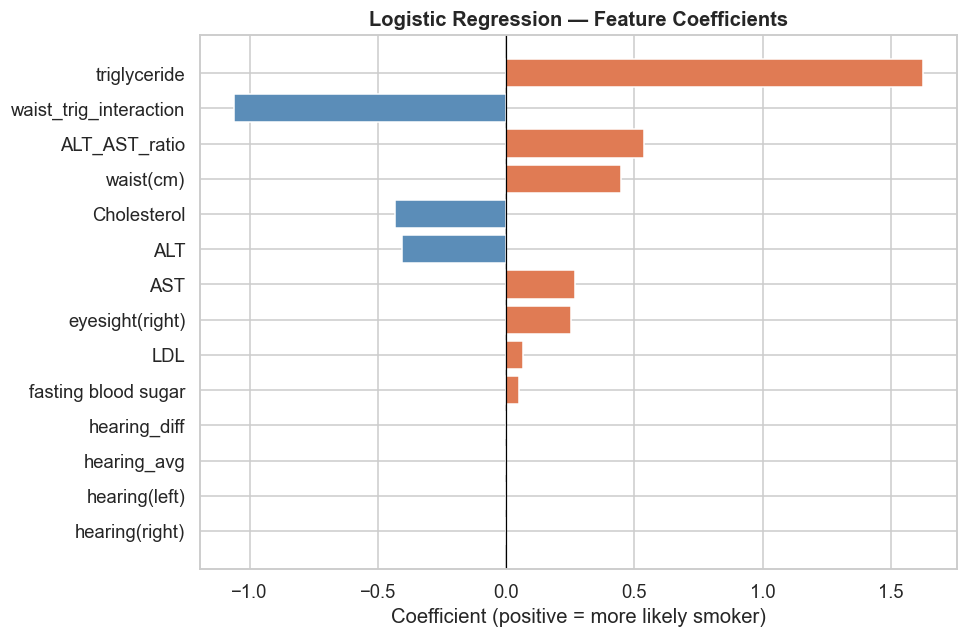


📌 Logistic Regression Strengths:
   • Interpretable coefficients showing feature direction & magnitude
   • Fast to train, works well for linearly separable data
   • Provides calibrated probabilities

⚠️  Weaknesses:
   • Assumes linear decision boundary — may miss complex patterns
   • Sensitive to outliers and multicollinearity


In [13]:
# ══ Logistic Regression ════════════════════════════════════════════════════
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_scaled, y_train_clean)

lr_val_pred = lr_model.predict(X_val_scaled)
lr_val_prob = lr_model.predict_proba(X_val_scaled)[:, 1]

lr_result = evaluate_model("Logistic Regression", y_val, lr_val_pred, lr_val_prob)
results.append(lr_result)

# Feature Importance via coefficients
coef_df = pd.DataFrame({
    "Feature":     FEAT_NAMES_FE,
    "Coefficient": lr_model.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=True)

plt.figure(figsize=(9, 6))
colors = ["#E07B54" if c > 0 else "#5B8DB8" for c in coef_df["Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression — Feature Coefficients", fontweight="bold")
plt.xlabel("Coefficient (positive = more likely smoker)")
plt.tight_layout()
plt.savefig("model_lr_coefficients.png", bbox_inches="tight")
plt.show()

print("\n📌 Logistic Regression Strengths:")
print("   • Interpretable coefficients showing feature direction & magnitude")
print("   • Fast to train, works well for linearly separable data")
print("   • Provides calibrated probabilities")
print("\n⚠️  Weaknesses:")
print("   • Assumes linear decision boundary — may miss complex patterns")
print("   • Sensitive to outliers and multicollinearity")


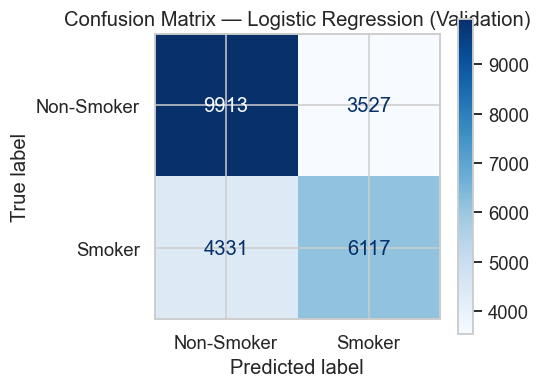

In [14]:
# Confusion matrix — Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, lr_val_pred,
    display_labels=["Non-Smoker", "Smoker"],
    cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix — Logistic Regression (Validation)")
plt.tight_layout()
plt.savefig("model_lr_cm.png", bbox_inches="tight")
plt.show()


### 3.2 Model 2 — Gaussian Naïve Bayes (Probabilistic Model)


──────────────────────────────────────────────────
  Gaussian Naïve Bayes
──────────────────────────────────────────────────
  Accuracy : 0.6664
  Precision: 0.6169
  Recall   : 0.6260
  F1-Score : 0.6214
  ROC-AUC  : 0.7219


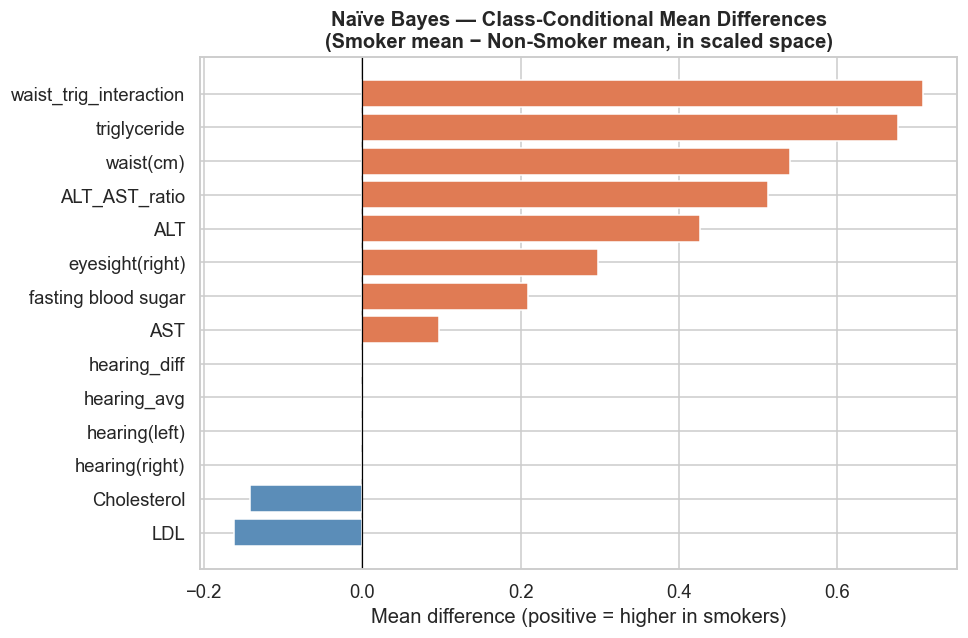


📌 Naïve Bayes Assumptions:
   • Feature independence: P(x1,x2,...,xn | y) = ∏ P(xi | y)
   • Gaussian distribution: each feature follows N(μ, σ²) per class
   • Class probability: P(y|X) ∝ P(y) · ∏ P(xi|y)  [Bayes Theorem]

📌 Naïve Bayes Strengths:
   • Extremely fast training and inference
   • Works well with small datasets
   • Natural probabilistic output

⚠️  Weaknesses:
   • Feature independence assumption is often violated in real data
   • Gaussian assumption may not fit all features


In [15]:
# ══ Gaussian Naïve Bayes ═══════════════════════════════════════════════════
gnb_model = GaussianNB()
gnb_model.fit(X_train_scaled, y_train_clean)

gnb_val_pred = gnb_model.predict(X_val_scaled)
gnb_val_prob = gnb_model.predict_proba(X_val_scaled)[:, 1]

gnb_result = evaluate_model("Gaussian Naïve Bayes", y_val, gnb_val_pred, gnb_val_prob)
results.append(gnb_result)

# Class-conditional mean for each feature
class_means = pd.DataFrame({
    "Feature":      FEAT_NAMES_FE,
    "Mean_Class0":  gnb_model.theta_[0],
    "Mean_Class1":  gnb_model.theta_[1],
    "Difference":   gnb_model.theta_[1] - gnb_model.theta_[0]
}).sort_values("Difference", ascending=True)

plt.figure(figsize=(9, 6))
colors = ["#E07B54" if d > 0 else "#5B8DB8" for d in class_means["Difference"]]
plt.barh(class_means["Feature"], class_means["Difference"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Naïve Bayes — Class-Conditional Mean Differences\n"
          "(Smoker mean − Non-Smoker mean, in scaled space)", fontweight="bold")
plt.xlabel("Mean difference (positive = higher in smokers)")
plt.tight_layout()
plt.savefig("model_gnb_means.png", bbox_inches="tight")
plt.show()

print("\n📌 Naïve Bayes Assumptions:")
print("   • Feature independence: P(x1,x2,...,xn | y) = ∏ P(xi | y)")
print("   • Gaussian distribution: each feature follows N(μ, σ²) per class")
print("   • Class probability: P(y|X) ∝ P(y) · ∏ P(xi|y)  [Bayes Theorem]")
print("\n📌 Naïve Bayes Strengths:")
print("   • Extremely fast training and inference")
print("   • Works well with small datasets")
print("   • Natural probabilistic output")
print("\n⚠️  Weaknesses:")
print("   • Feature independence assumption is often violated in real data")
print("   • Gaussian assumption may not fit all features")


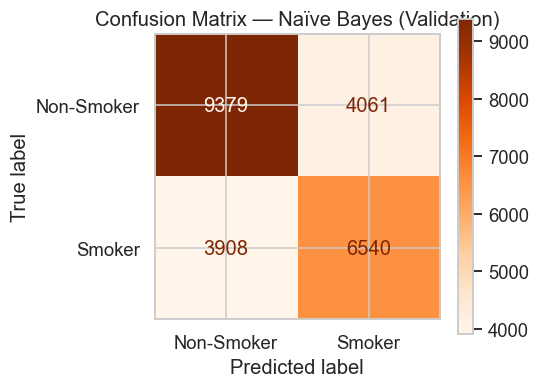

In [16]:
# Confusion matrix — Naïve Bayes
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, gnb_val_pred,
    display_labels=["Non-Smoker", "Smoker"],
    cmap="Oranges", ax=ax
)
ax.set_title("Confusion Matrix — Naïve Bayes (Validation)")
plt.tight_layout()
plt.savefig("model_gnb_cm.png", bbox_inches="tight")
plt.show()


### 3.3 Model 3 — Neural Network (Keras / TensorFlow)

In [17]:
# ══ Neural Network ══════════════════════════════════════════════════════════
n_features = X_train_scaled.shape[1]

def build_nn(dropout_rate=0.3, learning_rate=1e-3, units_1=128, units_2=64):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),

        layers.Dense(units_1, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),

        layers.Dense(units_2, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate / 2),

        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ], name="SmokingNN")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

nn_model = build_nn()
nn_model.summary()


Model: "SmokingNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 12,673 (49.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [20]:
# ── Training ─────────────────────────────────────────────────────────────────
early_stop = callbacks.EarlyStopping(
    monitor="val_auc", patience=15, restore_best_weights=True, mode="max"
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=7, min_lr=1e-5, verbose=0
)

history = nn_model.fit(
    X_train_scaled, y_train_clean,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")


Epoch 1/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6960 - auc: 0.7619 - loss: 0.5672 - val_accuracy: 0.6812 - val_auc: 0.7476 - val_loss: 0.5826 - learning_rate: 3.1250e-05
Epoch 2/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6953 - auc: 0.7617 - loss: 0.5674 - val_accuracy: 0.6806 - val_auc: 0.7476 - val_loss: 0.5826 - learning_rate: 3.1250e-05
Epoch 3/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6955 - auc: 0.7613 - loss: 0.5679 - val_accuracy: 0.6805 - val_auc: 0.7476 - val_loss: 0.5826 - learning_rate: 3.1250e-05
Epoch 4/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6957 - auc: 0.7617 - loss: 0.5675 - val_accuracy: 0.6802 - val_auc: 0.7476 - val_loss: 0.5826 - learning_rate: 3.1250e-05
Epoch 5/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6950 - auc: 0.7621 - loss: 0.5673 - val_accuracy: 0.6805 - val_auc: 0.7476 - val_loss: 0.5827 - learning_rate: 3.1250e-05
Epoch 6/100
359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - 

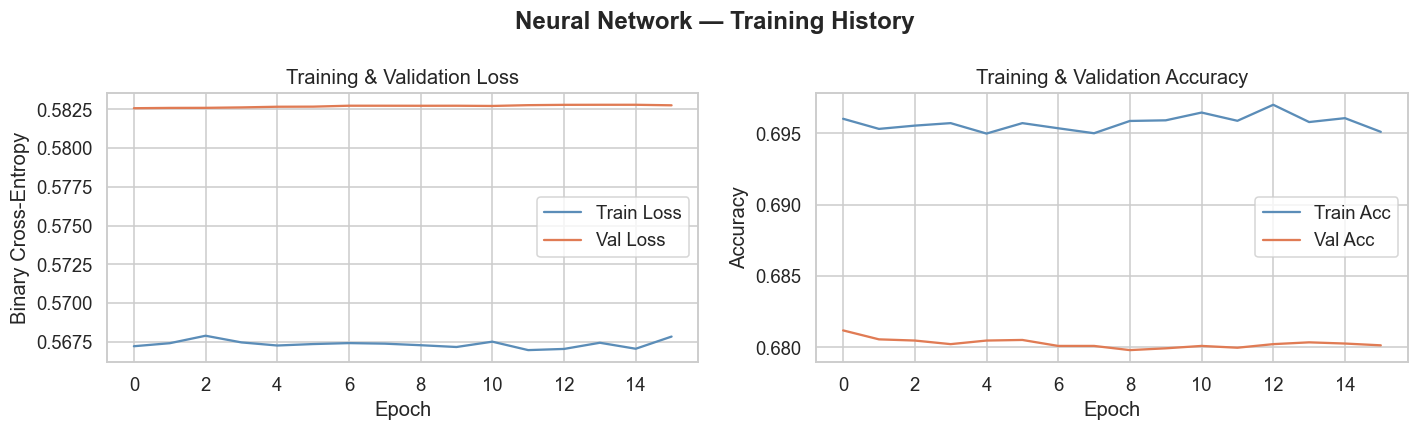

In [21]:
# ── Training curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["loss"],     label="Train Loss", color="#5B8DB8")
axes[0].plot(history.history["val_loss"], label="Val Loss",   color="#E07B54")
axes[0].set_title("Training & Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross-Entropy")
axes[0].legend()

axes[1].plot(history.history["accuracy"],     label="Train Acc", color="#5B8DB8")
axes[1].plot(history.history["val_accuracy"], label="Val Acc",   color="#E07B54")
axes[1].set_title("Training & Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Neural Network — Training History", fontweight="bold")
plt.tight_layout()
plt.savefig("model_nn_training.png", bbox_inches="tight")
plt.show()



──────────────────────────────────────────────────
  Neural Network
──────────────────────────────────────────────────
  Accuracy : 0.6812
  Precision: 0.6256
  Recall   : 0.6751
  F1-Score : 0.6494
  ROC-AUC  : 0.7477


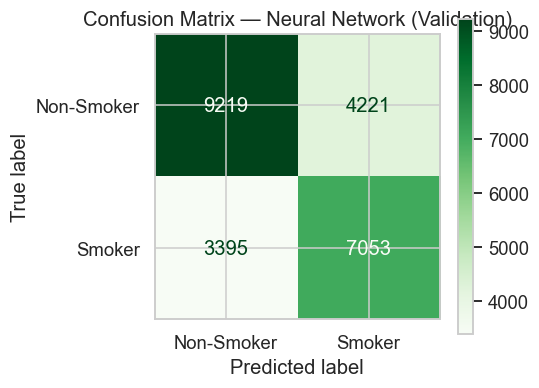


📌 Neural Network Strengths:
   • Captures non-linear and complex feature interactions
   • Scales well with more data
   • Flexible architecture (depth, width, activations)

⚠️  Weaknesses:
   • Requires more data and compute than simple models
   • Less interpretable (black box)
   • Sensitive to hyperparameters and random initialization


In [22]:
# ── Evaluate NN ──────────────────────────────────────────────────────────────
nn_val_prob = nn_model.predict(X_val_scaled, verbose=0).flatten()
nn_val_pred = (nn_val_prob >= 0.5).astype(int)

nn_result = evaluate_model("Neural Network", y_val, nn_val_pred, nn_val_prob)
results.append(nn_result)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_val, nn_val_pred,
    display_labels=["Non-Smoker", "Smoker"],
    cmap="Greens", ax=ax
)
ax.set_title("Confusion Matrix — Neural Network (Validation)")
plt.tight_layout()
plt.savefig("model_nn_cm.png", bbox_inches="tight")
plt.show()

print("\n📌 Neural Network Strengths:")
print("   • Captures non-linear and complex feature interactions")
print("   • Scales well with more data")
print("   • Flexible architecture (depth, width, activations)")
print("\n⚠️  Weaknesses:")
print("   • Requires more data and compute than simple models")
print("   • Less interpretable (black box)")
print("   • Sensitive to hyperparameters and random initialization")


## 4. Hyperparameter Tuning

Grid Search is applied to Logistic Regression to find optimal hyperparameters.
The search is performed using 5-fold cross-validation on the training set.


In [23]:
# ══ Grid Search — Logistic Regression ══════════════════════════════════════
param_grid = {
    "C":        [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    "solver":   ["lbfgs", "liblinear"],
    "penalty":  ["l2"],
    "max_iter": [1000]
}

gs_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
gs_lr.fit(X_train_scaled, y_train_clean)

print(f"\n✅ Best parameters: {gs_lr.best_params_}")
print(f"   Best CV F1-score: {gs_lr.best_score_:.4f}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Best parameters: {'C': 10.0, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
   Best CV F1-score: 0.5998


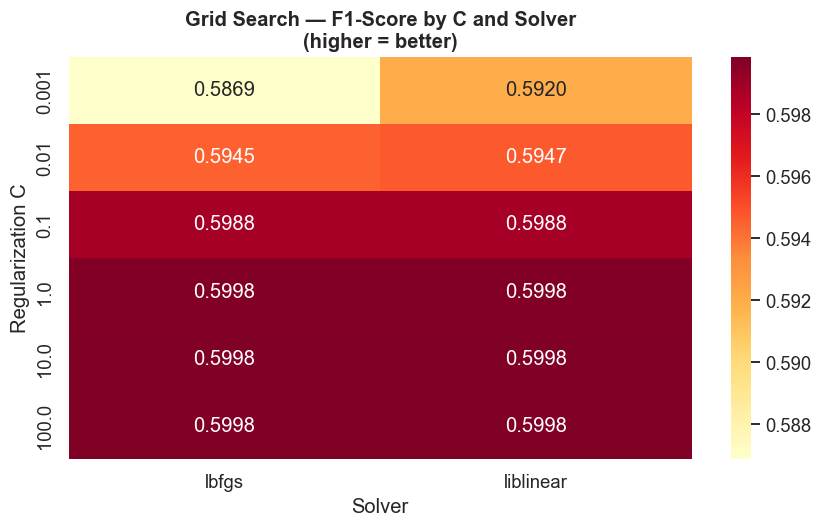

In [24]:
# ── Visualise Grid Search results ───────────────────────────────────────────
gs_results = pd.DataFrame(gs_lr.cv_results_)

pivot = gs_results.pivot_table(
    values="mean_test_score",
    index="param_C",
    columns="param_solver"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd")
plt.title("Grid Search — F1-Score by C and Solver\n(higher = better)", fontweight="bold")
plt.xlabel("Solver")
plt.ylabel("Regularization C")
plt.tight_layout()
plt.savefig("hp_gridsearch_heatmap.png", bbox_inches="tight")
plt.show()


In [25]:
# ── Retrain best LR and evaluate ────────────────────────────────────────────
best_lr = gs_lr.best_estimator_

best_lr_val_pred = best_lr.predict(X_val_scaled)
best_lr_val_prob = best_lr.predict_proba(X_val_scaled)[:, 1]

best_lr_result = evaluate_model("LR (Tuned)", y_val, best_lr_val_pred, best_lr_val_prob)
results.append(best_lr_result)

improvement = best_lr_result["F1-Score"] - lr_result["F1-Score"]
print(f"\nF1-Score improvement after tuning: {improvement:+.4f}")



──────────────────────────────────────────────────
  LR (Tuned)
──────────────────────────────────────────────────
  Accuracy : 0.6713
  Precision: 0.6345
  Recall   : 0.5862
  F1-Score : 0.6094
  ROC-AUC  : 0.7353

F1-Score improvement after tuning: +0.0005


## 5. Model Comparison & Final System

In [26]:
# ══ Comparison Table ════════════════════════════════════════════════════════
results_df = pd.DataFrame(results)
results_df = results_df.set_index("Model")
# Format numerics
for col in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    results_df[col] = results_df[col].apply(lambda x: f"{x:.4f}")
for col in ["ROC-AUC"]:
    results_df[col] = results_df[col].apply(
        lambda x: f"{float(x):.4f}" if x != "N/A" else "N/A"
    )

print("=" * 70)
print("  MODEL COMPARISON — VALIDATION SET")
print("=" * 70)
print(results_df.to_string())


  MODEL COMPARISON — VALIDATION SET
                     Accuracy Precision  Recall F1-Score ROC-AUC
Model                                                           
Logistic Regression    0.6710    0.6343  0.5855   0.6089  0.7353
Gaussian Naïve Bayes   0.6664    0.6169  0.6260   0.6214  0.7219
Neural Network         0.6812    0.6256  0.6751   0.6494  0.7477
LR (Tuned)             0.6713    0.6345  0.5862   0.6094  0.7353


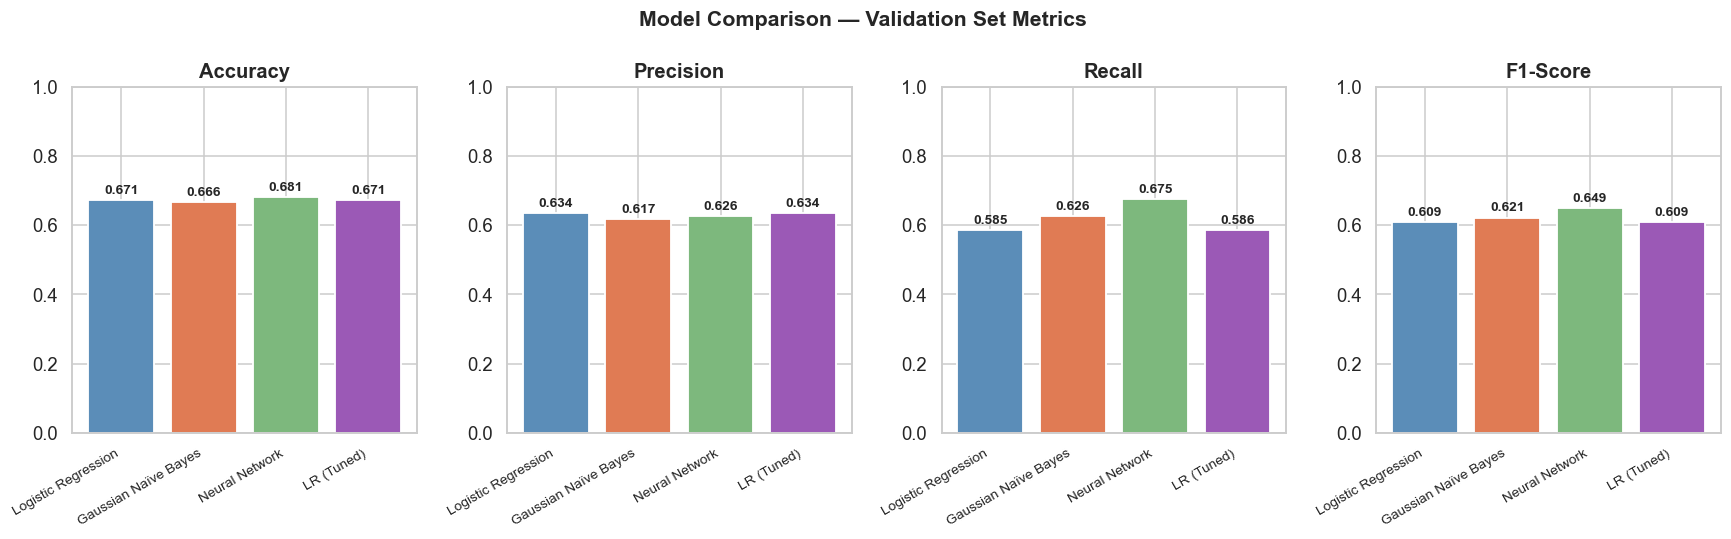

In [27]:
# ══ Bar chart comparison ════════════════════════════════════════════════════
compare_df = pd.DataFrame(results)
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

# Convert back to float for plotting
plot_df = compare_df.copy()
for m in metrics:
    plot_df[m] = plot_df[m].astype(float)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
colors = ["#5B8DB8", "#E07B54", "#7DB87D", "#9B59B6"]

for i, metric in enumerate(metrics):
    bars = axes[i].bar(plot_df["Model"], plot_df[metric],
                       color=colors, edgecolor="white", linewidth=1.2)
    axes[i].set_title(metric, fontweight="bold")
    axes[i].set_ylim(0, 1.0)
    axes[i].set_xticklabels(plot_df["Model"], rotation=30, ha="right", fontsize=9)
    for bar, val in zip(bars, plot_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01, f"{val:.3f}",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Model Comparison — Validation Set Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("comparison_bar_chart.png", bbox_inches="tight")
plt.show()


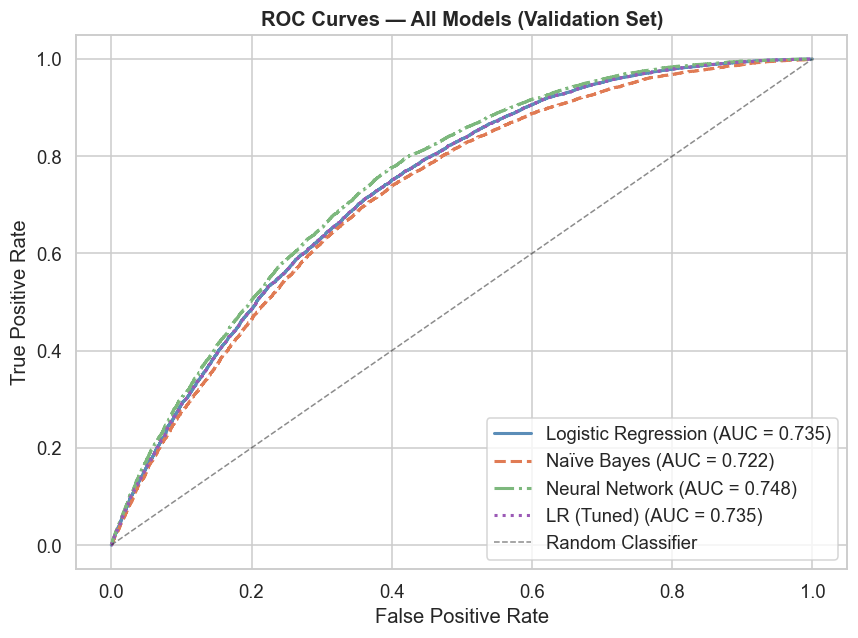

In [28]:
# ══ ROC Curves ══════════════════════════════════════════════════════════════
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

model_probs = [
    ("Logistic Regression", lr_val_prob),
    ("Naïve Bayes",         gnb_val_prob),
    ("Neural Network",      nn_val_prob),
    ("LR (Tuned)",          best_lr_val_prob),
]
line_styles = ["-", "--", "-.", ":"]
colors_roc  = ["#5B8DB8", "#E07B54", "#7DB87D", "#9B59B6"]

for (name, probs), ls, col in zip(model_probs, line_styles, colors_roc):
    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linestyle=ls, color=col, lw=2,
             label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1], "k--", lw=1, alpha=0.5, label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models (Validation Set)", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("comparison_roc_curves.png", bbox_inches="tight")
plt.show()


In [29]:
# ══ Final System — Best Model Evaluated on TEST SET ════════════════════════
# Determine best model by F1-Score on validation set
val_f1_scores = {
    "Logistic Regression": float(compare_df.loc[compare_df["Model"]=="Logistic Regression", "F1-Score"].values[0]),
    "Naïve Bayes":         float(compare_df.loc[compare_df["Model"]=="Gaussian Naïve Bayes", "F1-Score"].values[0]),
    "Neural Network":      float(compare_df.loc[compare_df["Model"]=="Neural Network", "F1-Score"].values[0]),
    "LR (Tuned)":          float(compare_df.loc[compare_df["Model"]=="LR (Tuned)", "F1-Score"].values[0]),
}

best_model_name = max(val_f1_scores, key=val_f1_scores.get)
print(f"\n🏆 Best model on validation set: {best_model_name}")
print(f"   Validation F1: {val_f1_scores[best_model_name]:.4f}")

# Map name to model object
model_map = {
    "Logistic Regression": (lr_model,    X_test_scaled, None),
    "Naïve Bayes":         (gnb_model,   X_test_scaled, None),
    "Neural Network":      (nn_model,    X_test_scaled, "keras"),
    "LR (Tuned)":          (best_lr,     X_test_scaled, None),
}

final_model, X_test_final, model_type = model_map[best_model_name]

if model_type == "keras":
    test_prob = final_model.predict(X_test_final, verbose=0).flatten()
    test_pred = (test_prob >= 0.5).astype(int)
else:
    test_pred = final_model.predict(X_test_final)
    test_prob = final_model.predict_proba(X_test_final)[:, 1]

print(f"\n{'='*55}")
print(f"  FINAL SYSTEM RESULTS — TEST SET ({best_model_name})")
print(f"{'='*55}")
print(classification_report(y_test, test_pred,
                             target_names=["Non-Smoker", "Smoker"]))

final_auc = roc_auc_score(y_test, test_prob)
print(f"  ROC-AUC: {final_auc:.4f}")



🏆 Best model on validation set: Neural Network
   Validation F1: 0.6494

  FINAL SYSTEM RESULTS — TEST SET (Neural Network)
              precision    recall  f1-score   support

  Non-Smoker       0.74      0.70      0.72     13441
      Smoker       0.64      0.68      0.66     10448

    accuracy                           0.69     23889
   macro avg       0.69      0.69      0.69     23889
weighted avg       0.69      0.69      0.69     23889

  ROC-AUC: 0.7539


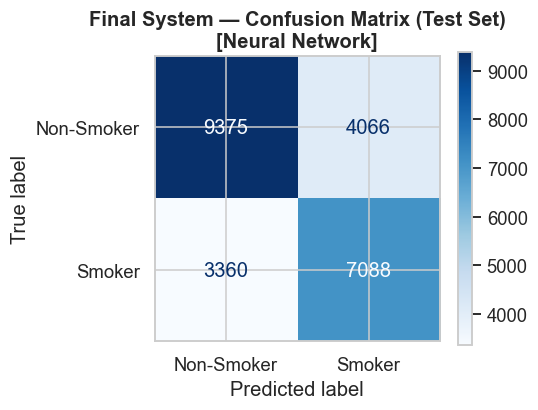


✅ Final System Complete!
   Best model: Neural Network
   Test Accuracy : 0.6891
   Test F1-Score : 0.6562
   Test ROC-AUC  : 0.7539


In [30]:
# ── Final confusion matrix on test set ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred,
    display_labels=["Non-Smoker", "Smoker"],
    cmap="Blues", ax=ax
)
ax.set_title(f"Final System — Confusion Matrix (Test Set)\n[{best_model_name}]",
             fontweight="bold")
plt.tight_layout()
plt.savefig("final_confusion_matrix.png", bbox_inches="tight")
plt.show()

print("\n✅ Final System Complete!")
print(f"   Best model: {best_model_name}")
print(f"   Test Accuracy : {accuracy_score(y_test, test_pred):.4f}")
print(f"   Test F1-Score : {f1_score(y_test, test_pred):.4f}")
print(f"   Test ROC-AUC  : {final_auc:.4f}")


In [31]:
# ══ Summary Report ══════════════════════════════════════════════════════════
print("""
╔══════════════════════════════════════════════════════════════╗
║              ASSIGNMENT 3 — FINAL SUMMARY                    ║
╠══════════════════════════════════════════════════════════════╣
║  FEATURE ENGINEERING:                                         ║
║  ✓ Outlier removal via IQR method                             ║
║  ✓ Log-transform on skewed features                           ║
║  ✓ StandardScaler normalization (zero mean, unit variance)   ║
║  ✓ MinMaxScaler & RobustScaler also demonstrated             ║
║  ✓ New interaction/ratio features created                     ║
║                                                               ║
║  MODELS TRAINED:                                              ║
║  ✓ Logistic Regression (linear, interpretable)               ║
║  ✓ Gaussian Naïve Bayes (probabilistic, fast)                ║
║  ✓ Neural Network — 3-layer MLP with Dropout + BN            ║
║                                                               ║
║  HYPERPARAMETER TUNING:                                       ║
║  ✓ Grid Search (5-fold CV) on Logistic Regression            ║
║  ✓ Tuned: C (regularization) and solver                       ║
║                                                               ║
║  FINAL SYSTEM:                                                ║
║  ✓ Best model selected by validation F1-Score                 ║
║  ✓ Final evaluation on held-out test set                      ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║              ASSIGNMENT 3 — FINAL SUMMARY                    ║
╠══════════════════════════════════════════════════════════════╣
║  FEATURE ENGINEERING:                                         ║
║  ✓ Outlier removal via IQR method                             ║
║  ✓ Log-transform on skewed features                           ║
║  ✓ StandardScaler normalization (zero mean, unit variance)   ║
║  ✓ MinMaxScaler & RobustScaler also demonstrated             ║
║  ✓ New interaction/ratio features created                     ║
║                                                               ║
║  MODELS TRAINED:                                              ║
║  ✓ Logistic Regression (linear, interpretable)               ║
║  ✓ Gaussian Naïve Bayes (probabilistic, fast)                ║
║  ✓ Neural Network — 3-layer MLP with Dropout + BN            ║
║                                                               ║
║  HYPERPARAMETER